In [48]:
import pickle
from pathlib import Path

import numpy as np
import tools_motn

# 批量处理 MOTN 文件
MOTN_DIR = Path("AR")
SAVE_PATH = Path("data/ar_motn.pkl")
TARGET_HZ = 200.0
GRIPPER_WIDTH = 0.0

motn_files = sorted(MOTN_DIR.rglob("*.motn"))

### 批量处理并保存

In [49]:
def matrix_to_rotvec(mat):
    mat = np.asarray(mat, dtype=float)
    cos_angle = (np.trace(mat) - 1.0) / 2.0
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    angle = np.arccos(cos_angle)

    if angle < 1e-8:
        return np.zeros(3)

    axis = np.array(
        [
            mat[2, 1] - mat[1, 2],
            mat[0, 2] - mat[2, 0],
            mat[1, 0] - mat[0, 1],
        ]
    ) / (2.0 * np.sin(angle))

    return axis * angle


def matrices_to_rotvec(mats):
    return np.asarray([matrix_to_rotvec(mat) for mat in mats], dtype=float)


def pos_rot_to_tf(pos, rot):
    pos = np.asarray(pos, dtype=float)
    rot = np.asarray(rot, dtype=float)
    tf = np.broadcast_to(np.eye(4, dtype=float), pos.shape[:-1] + (4, 4)).copy()
    tf[..., :3, 3] = pos
    tf[..., :3, :3] = rot
    return tf


def _as_strictly_increasing_time(t):
    t = np.asarray(t, dtype=float)
    if t.ndim != 1 or len(t) < 2:
        raise ValueError("t must be a 1D array with at least two samples")
    if not np.all(np.diff(t) > 0):
        raise ValueError("t must be strictly increasing")
    return t


def make_uniform_time(t, target_hz, include_endpoint=True):
    t = _as_strictly_increasing_time(t)
    target_hz = float(target_hz)
    if target_hz <= 0:
        raise ValueError("target_hz must be positive")

    dt = 1.0 / target_hz
    duration = float(t[-1] - t[0])
    new_t = np.arange(0.0, duration + 1e-12, dt, dtype=float)

    if include_endpoint and not np.isclose(new_t[-1], duration, atol=1e-10, rtol=0.0):
        new_t = np.append(new_t, duration)

    return new_t


def cubic_hermite_interpolate(t, values, new_t):
    """Interpolate sampled values with the same C1 cubic Hermite curve as motn_to_pkl.py."""
    t = _as_strictly_increasing_time(t)
    values = np.asarray(values, dtype=float)
    new_t = np.asarray(new_t, dtype=float)

    if values.shape[0] != len(t):
        raise ValueError("values first dimension must match len(t)")
    if np.any(new_t < t[0] - 1e-12) or np.any(new_t > t[-1] + 1e-12):
        raise ValueError("new_t must lie inside the source time range")

    dt = np.diff(t)
    slopes = np.empty_like(values, dtype=float)
    slopes[0] = (values[1] - values[0]) / dt[0]
    slopes[-1] = (values[-1] - values[-2]) / dt[-1]
    slopes[1:-1] = (values[2:] - values[:-2]) / (t[2:] - t[:-2]).reshape(
        (-1,) + (1,) * (values.ndim - 1)
    )

    idx = np.searchsorted(t, new_t, side="right") - 1
    idx = np.clip(idx, 0, len(t) - 2)

    h = (t[idx + 1] - t[idx]).reshape((-1,) + (1,) * (values.ndim - 1))
    u = ((new_t - t[idx]) / (t[idx + 1] - t[idx])).reshape(
        (-1,) + (1,) * (values.ndim - 1)
    )

    h00 = 2.0 * u**3 - 3.0 * u**2 + 1.0
    h10 = u**3 - 2.0 * u**2 + u
    h01 = -2.0 * u**3 + 3.0 * u**2
    h11 = u**3 - u**2

    return (
        h00 * values[idx]
        + h10 * h * slopes[idx]
        + h01 * values[idx + 1]
        + h11 * h * slopes[idx + 1]
    )


def _normalize_quat(q):
    q = np.asarray(q, dtype=float)
    return q / np.linalg.norm(q, axis=-1, keepdims=True)


def _quat_conjugate(q):
    out = np.asarray(q, dtype=float).copy()
    out[..., 1:] *= -1.0
    return out


def _quat_multiply(a, b):
    aw, ax, ay, az = np.moveaxis(np.asarray(a, dtype=float), -1, 0)
    bw, bx, by, bz = np.moveaxis(np.asarray(b, dtype=float), -1, 0)
    return np.stack(
        (
            aw * bw - ax * bx - ay * by - az * bz,
            aw * bx + ax * bw + ay * bz - az * by,
            aw * by - ax * bz + ay * bw + az * bx,
            aw * bz + ax * by - ay * bx + az * bw,
        ),
        axis=-1,
    )


def _quat_log(q):
    q = _normalize_quat(q)
    v = q[..., 1:]
    v_norm = np.linalg.norm(v, axis=-1, keepdims=True)
    angle = np.arctan2(v_norm, q[..., :1])
    scale = np.divide(angle, v_norm, out=np.zeros_like(v_norm), where=v_norm > 1e-12)
    return np.concatenate((np.zeros_like(q[..., :1]), v * scale), axis=-1)


def _quat_exp(q):
    v = np.asarray(q, dtype=float)[..., 1:]
    angle = np.linalg.norm(v, axis=-1, keepdims=True)
    scale = np.divide(np.sin(angle), angle, out=np.ones_like(angle), where=angle > 1e-12)
    return _normalize_quat(np.concatenate((np.cos(angle), v * scale), axis=-1))


def _quat_slerp(q0, q1, u):
    q0 = _normalize_quat(q0)
    q1 = _normalize_quat(q1)
    u = np.asarray(u, dtype=float)

    dot = float(np.dot(q0, q1))
    if dot < 0.0:
        q1 = -q1
        dot = -dot
    dot = np.clip(dot, -1.0, 1.0)

    if dot > 0.9995:
        return _normalize_quat(q0 + u[..., None] * (q1 - q0))

    theta0 = np.arccos(dot)
    sin_theta0 = np.sin(theta0)
    theta = theta0 * u
    s0 = np.cos(theta) - dot * np.sin(theta) / sin_theta0
    s1 = np.sin(theta) / sin_theta0
    return _normalize_quat(s0[..., None] * q0 + s1[..., None] * q1)


def _continuous_quats(quats):
    quats = _normalize_quat(quats)
    out = quats.copy()
    for i in range(1, len(out)):
        if np.dot(out[i - 1], out[i]) < 0.0:
            out[i] *= -1.0
    return out


def _matrix_to_quat_np(mat):
    mat = np.asarray(mat, dtype=float)
    flat = mat.reshape((-1, 3, 3))
    quats = np.empty((len(flat), 4), dtype=float)

    for i, m in enumerate(flat):
        trace = np.trace(m)
        if trace > 0.0:
            s = np.sqrt(trace + 1.0) * 2.0
            quats[i] = [
                0.25 * s,
                (m[2, 1] - m[1, 2]) / s,
                (m[0, 2] - m[2, 0]) / s,
                (m[1, 0] - m[0, 1]) / s,
            ]
        elif m[0, 0] > m[1, 1] and m[0, 0] > m[2, 2]:
            s = np.sqrt(1.0 + m[0, 0] - m[1, 1] - m[2, 2]) * 2.0
            quats[i] = [
                (m[2, 1] - m[1, 2]) / s,
                0.25 * s,
                (m[0, 1] + m[1, 0]) / s,
                (m[0, 2] + m[2, 0]) / s,
            ]
        elif m[1, 1] > m[2, 2]:
            s = np.sqrt(1.0 + m[1, 1] - m[0, 0] - m[2, 2]) * 2.0
            quats[i] = [
                (m[0, 2] - m[2, 0]) / s,
                (m[0, 1] + m[1, 0]) / s,
                0.25 * s,
                (m[1, 2] + m[2, 1]) / s,
            ]
        else:
            s = np.sqrt(1.0 + m[2, 2] - m[0, 0] - m[1, 1]) * 2.0
            quats[i] = [
                (m[1, 0] - m[0, 1]) / s,
                (m[0, 2] + m[2, 0]) / s,
                (m[1, 2] + m[2, 1]) / s,
                0.25 * s,
            ]

    return _normalize_quat(quats.reshape(mat.shape[:-2] + (4,)))


def _quat_to_matrix_np(quat):
    quat = _normalize_quat(quat)
    w, x, y, z = np.moveaxis(quat, -1, 0)
    two_s = 2.0 / np.sum(quat * quat, axis=-1)
    return np.stack(
        (
            1 - two_s * (y * y + z * z),
            two_s * (x * y - z * w),
            two_s * (x * z + y * w),
            two_s * (x * y + z * w),
            1 - two_s * (x * x + z * z),
            two_s * (y * z - x * w),
            two_s * (x * z - y * w),
            two_s * (y * z + x * w),
            1 - two_s * (x * x + y * y),
        ),
        axis=-1,
    ).reshape(quat.shape[:-1] + (3, 3))


def _squad_controls(quats):
    quats = _continuous_quats(quats)
    controls = quats.copy()
    for i in range(1, len(quats) - 1):
        inv_q = _quat_conjugate(quats[i])
        log_prev = _quat_log(_quat_multiply(inv_q, quats[i - 1]))
        log_next = _quat_log(_quat_multiply(inv_q, quats[i + 1]))
        controls[i] = _quat_multiply(
            quats[i],
            _quat_exp(-0.25 * (log_prev + log_next)),
        )
    return _continuous_quats(controls)


def squad_interpolate(t, quats, new_t):
    """C1 quaternion interpolation using SQUAD, with quaternions in wxyz order."""
    t = _as_strictly_increasing_time(t)
    quats = _continuous_quats(np.asarray(quats, dtype=float))
    new_t = np.asarray(new_t, dtype=float)

    if quats.shape != (len(t), 4):
        raise ValueError("quats must have shape (len(t), 4)")
    if np.any(new_t < t[0] - 1e-12) or np.any(new_t > t[-1] + 1e-12):
        raise ValueError("new_t must lie inside the source time range")

    idx = np.searchsorted(t, new_t, side="right") - 1
    idx = np.clip(idx, 0, len(t) - 2)
    controls = _squad_controls(quats)

    out = np.empty((len(new_t), 4), dtype=float)
    for interval in np.unique(idx):
        mask = idx == interval
        u = (new_t[mask] - t[interval]) / (t[interval + 1] - t[interval])
        q01 = _quat_slerp(quats[interval], quats[interval + 1], u)
        s01 = _quat_slerp(controls[interval], controls[interval + 1], u)
        blend = 2.0 * u * (1.0 - u)
        out[mask] = np.asarray(
            [_quat_slerp(q01[j], s01[j], blend[j]) for j in range(len(u))],
            dtype=float,
        )

    return _continuous_quats(out)


def slerp_interpolate(t, quats, new_t):
    """Quaternion SLERP interpolation, with quaternions in wxyz order."""
    t = _as_strictly_increasing_time(t)
    quats = _continuous_quats(np.asarray(quats, dtype=float))
    new_t = np.asarray(new_t, dtype=float)

    idx = np.searchsorted(t, new_t, side="right") - 1
    idx = np.clip(idx, 0, len(t) - 2)

    out = np.empty((len(new_t), 4), dtype=float)
    for interval in np.unique(idx):
        mask = idx == interval
        u = (new_t[mask] - t[interval]) / (t[interval + 1] - t[interval])
        out[mask] = _quat_slerp(quats[interval], quats[interval + 1], u)

    return _continuous_quats(out)


def resample_episode(
    episode,
    target_hz=TARGET_HZ,
    include_endpoint=True,
    rot_method="squad",
):
    """Resample like motn_to_pkl.py: cubic position/gripper + quaternion SQUAD rotation."""
    t = _as_strictly_increasing_time(episode["t"])
    new_t = make_uniform_time(t, target_hz, include_endpoint=include_endpoint)

    ee_tf   = np.asarray(episode["ee_tf"], dtype=float)
    ee_pos  = cubic_hermite_interpolate(t, ee_tf[:, :3, 3], new_t)
    ee_quat = _matrix_to_quat_np(ee_tf[:, :3, :3])

    if rot_method == "squad":
        new_quat = squad_interpolate(t, ee_quat, new_t)
    elif rot_method == "slerp":
        new_quat = slerp_interpolate(t, ee_quat, new_t)
    else:
        raise ValueError("rot_method must be 'squad' or 'slerp'")

    new_rot = _quat_to_matrix_np(new_quat)
    new_tf = pos_rot_to_tf(ee_pos, new_rot)

    out = dict(episode)
    out["t"] = new_t
    out["ee_tf"] = new_tf.astype(episode["ee_tf"].dtype, copy=False)
    out["ee_pos"] = ee_pos.astype(episode["ee_pos"].dtype, copy=False)
    out["ee_axis_angle"] = matrices_to_rotvec(new_rot)
    out["gripper_width"] = cubic_hermite_interpolate(t, episode["gripper_width"], new_t)
    return out


def keep_save_keys(episode):
    return {
        "t": episode["t"],
        "ee_pos": episode["ee_pos"],
        "ee_axis_angle": episode["ee_axis_angle"],
        "gripper_width": episode["gripper_width"],
    }


def motn_to_traj(
    motn_path: Path,
    *,
    target_hz: float | None = TARGET_HZ,
    gripper_width: float = GRIPPER_WIDTH,
    rot_resample_method: str = "squad",
):
    # .motn file to transform matrix sequence
    processed = tools_motn.process_tracking_data(path=motn_path)
    ee_tf = processed["tf_target"].astype(np.float32)

    # tf to position + axis-angle
    episode = {
        "t": processed["t"].astype(float),
        "ee_tf": ee_tf,
        "ee_pos": ee_tf[:, :3, 3],
        "ee_axis_angle": matrices_to_rotvec(ee_tf[:, :3, :3]),
        "gripper_width": np.full(len(processed["t"]), gripper_width, dtype=float),
    }

    # resample to 200Hz if needed
    if target_hz is not None:
        episode = resample_episode(
            episode,
            target_hz=target_hz,
            rot_method=rot_resample_method,
        )

    return keep_save_keys(episode)


def motn_to_pkl(
    motn_dir: Path,
    save_path: Path,
    *,
    target_hz: float | None = TARGET_HZ,
    gripper_width: float = GRIPPER_WIDTH,
    rot_resample_method: str = "squad",
):
    motn_dir = Path(motn_dir)
    save_path = Path(save_path)

    motn_files = sorted(motn_dir.rglob("*.motn"))
    if len(motn_files) == 0:
        raise FileNotFoundError(f"No .motn files found under {motn_dir}")

    data = []
    print("motn files:", len(motn_files))

    for motn_path in motn_files:
        episode = motn_to_traj(
            motn_path,
            target_hz=target_hz,
            gripper_width=gripper_width,
            rot_resample_method=rot_resample_method,
        )
        data.append(episode)

        duration = episode["t"][-1]
        fps = round((len(episode["t"]) - 1) / duration, 3) if duration > 0 else 0
        print(
            motn_path.name,
            "frames =", len(episode["t"]),
            "duration =", round(float(duration), 3),
            "fps =", fps,
        )

    save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "wb") as f:
        pickle.dump(data, f)

    print("saved:", save_path)
    print("num trajectories:", len(data))
    return data

In [50]:
trajectories = motn_to_pkl(
    MOTN_DIR,
    SAVE_PATH,
    target_hz=TARGET_HZ,
    gripper_width=GRIPPER_WIDTH,
)

motn files: 94
2026_05_10_1657480430.motn frames = 888 duration = 4.433 fps = 200.075
2026_05_10_1658011620.motn frames = 1021 duration = 5.1 fps = 200.0
2026_05_10_1658389050.motn frames = 691 duration = 3.45 fps = 200.0
2026_05_10_1658459530.motn frames = 758 duration = 3.783 fps = 200.088
2026_05_10_1706048040.motn frames = 785 duration = 3.917 fps = 200.17
2026_05_10_1706176230.motn frames = 698 duration = 3.483 fps = 200.096
2026_05_12_1645225600.motn frames = 2201 duration = 11.0 fps = 200.0
2026_05_12_1645406310.motn frames = 2291 duration = 11.45 fps = 200.0
2026_05_12_1645590510.motn frames = 1848 duration = 9.233 fps = 200.036
2026_05_12_1646158880.motn frames = 2085 duration = 10.417 fps = 200.064
2026_05_12_1646311910.motn frames = 2211 duration = 11.05 fps = 200.0
2026_05_12_1646501700.motn frames = 2445 duration = 12.217 fps = 200.055
2026_05_12_1647070830.motn frames = 2545 duration = 12.717 fps = 200.052
2026_05_12_1647266860.motn frames = 2651 duration = 13.25 fps = 20

### Debug 绘图

In [51]:
import matplotlib.pyplot as plt

def PLOT_RAW(raw):
    pos_source   = raw["position_source"]
    euler_source = raw["euler_source"]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(pos_source[:, 0], label="X")
    plt.plot(pos_source[:, 1], label="Y")
    plt.plot(pos_source[:, 2], label="Z")
    plt.xlabel("Time")
    plt.ylabel("Position")
    plt.title("Position over Time")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(euler_source[:, 0], label="X")
    plt.plot(euler_source[:, 1], label="Y")
    plt.plot(euler_source[:, 2], label="Z")
    plt.xlabel("Time")
    plt.ylabel("Euler Angles")
    plt.title("Euler Angles over Time")
    plt.legend()

    plt.tight_layout()
    plt.show()

def PLOT_POS_RAW(raw, type="xy"):
    match type:
        case "xy":
            plt.plot(raw["position_source"][:, 0], raw["position_source"][:, 1])
            plt.xlabel("X Position")
            plt.ylabel("Y Position")
            plt.title("XY Position Plot")
        case "xz":
            plt.plot(raw["position_source"][:, 0], raw["position_source"][:, 2])
            plt.xlabel("X Position")
            plt.ylabel("Z Position")
            plt.title("XZ Position Plot")
        case "yz":
            plt.plot(raw["position_source"][:, 1], raw["position_source"][:, 2])
            plt.xlabel("Y Position")
            plt.ylabel("Z Position")
            plt.title("YZ Position Plot")
        case _:
            raise ValueError("type must be 'xy', 'xz', or 'yz'")
    plt.show()

def PLOT_3D(tf, 
            arrow_scale = 0.05, 
            interval: float = 0.1,
            view:str = "normal"):
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(tf[:, 0, 3], tf[:, 1, 3], tf[:, 2, 3])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # 绘制 orientation
    for i in range(0, len(tf), max(1, int(len(tf)*interval))):  # 每隔一定数量的帧绘制一个坐标轴
        T = tf[i]
        origin = T[:3, 3]
        x_axis = origin + T[:3, 0] * arrow_scale  # X轴，红色
        y_axis = origin + T[:3, 1] * arrow_scale  # Y轴，绿色
        z_axis = origin + T[:3, 2] * arrow_scale  # Z轴，蓝色
        ax.plot([origin[0], x_axis[0]], [origin[1], x_axis[1]], [origin[2], x_axis[2]], color='r')
        ax.plot([origin[0], y_axis[0]], [origin[1], y_axis[1]], [origin[2], y_axis[2]], color='g')
        ax.plot([origin[0], z_axis[0]], [origin[1], z_axis[1]], [origin[2], z_axis[2]], color='b')

    match view.lower():
        case "normal":
            pass  # 使用默认视角
        case "top":
            # ax.view_init(elev=90, azim=-90)
            ax.view_init(elev=90, azim=-180)
        case "side":
            ax.view_init(elev=0, azim=-90)
        case "front":
            ax.view_init(elev=0, azim=0)


    xyz = tf[:, :3, 3]
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))
    ax.set_proj_type("ortho")

    plt.show()

In [52]:
def axis_angle_to_matrix(axis_angle):
    axis_angle = np.asarray(axis_angle, dtype=float)
    angle = np.linalg.norm(axis_angle)
    if angle < 1e-8:
        return np.eye(3)

    axis = axis_angle / angle
    x, y, z = axis
    c = np.cos(angle)
    s = np.sin(angle)
    C = 1.0 - c

    return np.array(
        [
            [c + x * x * C, x * y * C - z * s, x * z * C + y * s],
            [y * x * C + z * s, c + y * y * C, y * z * C - x * s],
            [z * x * C - y * s, z * y * C + x * s, c + z * z * C],
        ],
        dtype=float,
    )


def load_pkl_trajectories(path=SAVE_PATH):
    with open(path, "rb") as f:
        return pickle.load(f)


def _set_equal_3d_axes(ax, xyz):
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2
    if radius < 1e-8:
        radius = 1e-3

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))
    ax.set_proj_type("ortho")


def _apply_3d_view(ax, view):
    match view.lower():
        case "normal":
            pass
        case "top":
            ax.view_init(elev=90, azim=-180)
        case "side":
            ax.view_init(elev=0, azim=-90)
        case "front":
            ax.view_init(elev=0, azim=0)
        case _:
            raise ValueError("3D view must be 'normal', 'top', 'side', or 'front'")


def PLOT_PKL(
    index: int = 0,
    view: str = "xy",
    num: int = 4,
    *,
    data=None,
    pkl_path=SAVE_PATH,
    interval: float = 0.02,
    axis_len: float = 0.04,
):
    if data is None:
        data = load_pkl_trajectories(pkl_path)

    if num <= 0:
        raise ValueError("num must be positive")
    if index < 0 or index >= len(data):
        raise IndexError(f"index must be in [0, {len(data) - 1}]")

    end = min(index + num, len(data))
    plot_indices = list(range(index, end))
    cols = min(4, len(plot_indices))
    rows = int(np.ceil(len(plot_indices) / cols))

    view = view.lower()
    is_3d = view in {"normal", "top", "side", "front"}
    projection_axes = {
        "xy": (0, 1, "X", "Y"),
        "xz": (0, 2, "X", "Z"),
        "yz": (1, 2, "Y", "Z"),
    }

    if not is_3d and view not in projection_axes:
        raise ValueError("view must be 'xy', 'xz', 'yz', 'normal', 'top', 'side', or 'front'")

    fig = plt.figure(figsize=(4.5 * cols, 4.5 * rows))

    for plot_id, data_idx in enumerate(plot_indices):
        traj = np.asarray(data[data_idx]["ee_pos"], dtype=float)
        axis_angle = np.asarray(data[data_idx]["ee_axis_angle"], dtype=float)
        step = max(1, int(len(traj) * interval))

        if is_3d:
            ax = fig.add_subplot(rows, cols, plot_id + 1, projection="3d")
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linewidth=1.5)
            ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], c="g", marker="o", s=35)
            ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], c="r", marker="x", s=35)

            for i in range(0, len(traj), step):
                p = traj[i]
                rot = axis_angle_to_matrix(axis_angle[i])
                ax.quiver(p[0], p[1], p[2], rot[0, 0], rot[1, 0], rot[2, 0], length=axis_len, normalize=True, color="r")
                ax.quiver(p[0], p[1], p[2], rot[0, 1], rot[1, 1], rot[2, 1], length=axis_len, normalize=True, color="g")
                ax.quiver(p[0], p[1], p[2], rot[0, 2], rot[1, 2], rot[2, 2], length=axis_len, normalize=True, color="b")

            _set_equal_3d_axes(ax, traj)
            _apply_3d_view(ax, view)
            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_zlabel("Z")
        else:
            a, b, xlabel, ylabel = projection_axes[view]
            ax = fig.add_subplot(rows, cols, plot_id + 1)
            ax.plot(traj[:, a], traj[:, b], linewidth=1.5)
            ax.scatter(traj[0, a], traj[0, b], c="g", marker="o", s=35)
            ax.scatter(traj[-1, a], traj[-1, b], c="r", marker="x", s=35)

            for i in range(0, len(traj), step):
                p = traj[i]
                rot = axis_angle_to_matrix(axis_angle[i])
                ax.quiver(p[a], p[b], rot[a, 0] * axis_len, rot[b, 0] * axis_len, angles="xy", scale_units="xy", scale=1, color="r")
                ax.quiver(p[a], p[b], rot[a, 1] * axis_len, rot[b, 1] * axis_len, angles="xy", scale_units="xy", scale=1, color="g")
                ax.quiver(p[a], p[b], rot[a, 2] * axis_len, rot[b, 2] * axis_len, angles="xy", scale_units="xy", scale=1, color="b")

            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.axis("equal")
            ax.grid(True)

        ax.set_title(f"Trajectory index: {data_idx}")

    plt.tight_layout()
    plt.show()

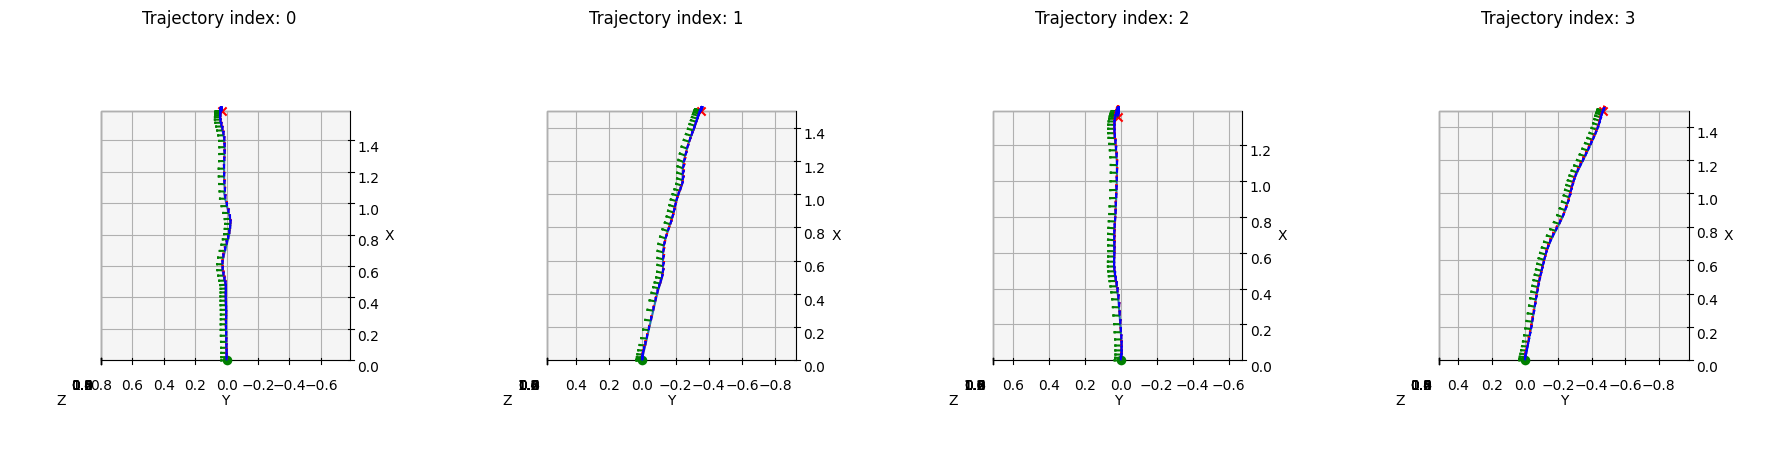

In [53]:
PLOT_PKL(index=0, view="top", num=4)

### 单文件 Debug 处理流程

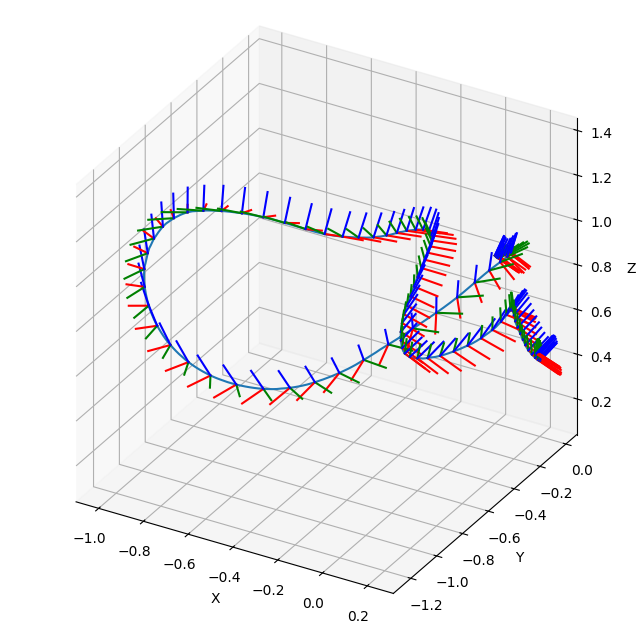

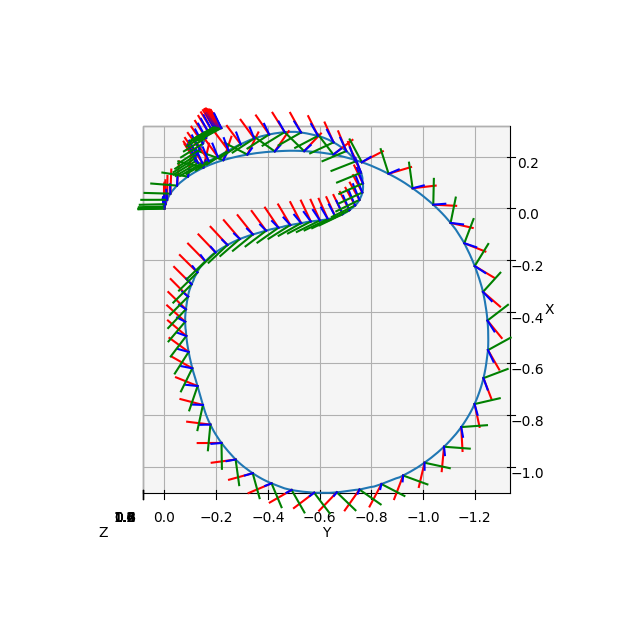

In [54]:
INPUT_PATH = Path("/home/ece-486/Documents/SP_PBL/umi-on-legs/AR/spin/2026_05_12_2021281130/2026_05_12_2021281130.motn")
INPUT_PATH = Path("/home/ece-486/Documents/SP_PBL/umi-on-legs/AR/reach_forward/2026_05_10_2137198790/2026_05_10_2137198790.motn")
INPUT_PATH = Path("/home/ece-486/Documents/SP_PBL/umi-on-legs/AR_test/2026_05_14_0052274540/2026_05_14_0052274540.motn")
INPUT_PATH = Path("/home/ece-486/Documents/SP_PBL/umi-on-legs/AR/rotate/2026_05_14_0107306890/2026_05_14_0107306890.motn")

single_data = tools_motn.process_tracking_data(path=INPUT_PATH)

# tf = single_data["tf_source"]
tf = single_data["tf_target"]

ARROW = 0.1
PLOT_3D(tf, arrow_scale=ARROW, interval=0.01, view="normal")
PLOT_3D(tf, arrow_scale=ARROW, interval=0.01, view="top")
# PLOT_3D(tf, arrow_scale=ARROW, interval=0.01, view="side")

In [55]:
# raw = tools_motn.load_motn(INPUT_PATH)
# PLOT_RAW(raw)
# PLOT_POS_RAW(raw, type="xy")
# PLOT_POS_RAW(raw, type="xz")
# PLOT_POS_RAW(raw, type="yz")